In [1]:
import duckdb
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

from pathlib import Path
os.chdir(Path().resolve().parent)

In [2]:
# подключаемся к базе
con = duckdb.connect('notebooks/credit_risk.db')

In [3]:
# только дефолтные кредиты
df = con.execute("""
    SELECT *
    FROM mart.features
    WHERE is_default = 1
      AND lgd_actual IS NOT NULL
      AND lgd_actual BETWEEN 0 AND 1
""").df()

print(f"Дефолтных кредитов: {df.shape[0]}")
print(f"\nРаспределение LGD:")
print(df['lgd_actual'].describe().round(3))

Дефолтных кредитов: 267774

Распределение LGD:
count    267774.000
mean          0.697
std           0.219
min           0.000
25%           0.566
50%           0.747
75%           0.872
max           1.000
Name: lgd_actual, dtype: float64


In [4]:
FEATURES_LGD = [
    'dti', 'fico_avg', 'annual_inc', 'loan_amnt',
    'installment', 'open_acc', 'revol_util', 'total_acc',
    'loan_to_income', 'payment_to_income', 'term_months',
    'home_ownership', 'purpose'
]

df_lgd = df[FEATURES_LGD + ['lgd_actual']].dropna()
df_lgd = pd.get_dummies(df_lgd,
                         columns=['home_ownership', 'purpose'],
                         drop_first=True)

FEATURES_LGD_ENC = [c for c in df_lgd.columns if c != 'lgd_actual']

X = df_lgd[FEATURES_LGD_ENC]
y = df_lgd['lgd_actual']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 214075, Test: 53519


In [5]:
def compute_lgd_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae  = np.mean(np.abs(y_true - y_pred))
    # среднее отклонение предсказанного LGD от фактического
    bias = np.mean(y_pred - y_true)
    return {
        "RMSE": round(rmse, 4),
        "R2":   round(r2, 4),
        "MAE":  round(mae, 4),
        "Bias": round(bias, 4)
    }

In [6]:
# Линейная регрессия
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test).clip(0, 1)  # обрезаем выход в [0,1]
metrics_lr = compute_lgd_metrics(y_test.values, y_pred_lr)

print("Линейная регрессия:")
for k, v in metrics_lr.items():
    print(f"  {k}: {v}")

Линейная регрессия:
  RMSE: 0.2042
  R2: 0.1331
  MAE: 0.1628
  Bias: 0.001


In [7]:
# Градиентный бустинг
gbm = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
    )
gbm.fit(X_train, y_train)
y_pred_gbm = gbm.predict(X_test).clip(0, 1)
metrics_gbm = compute_lgd_metrics(y_test.values, y_pred_gbm)
        
print("\nGradient Boosting:")
for k, v in metrics_gbm.items():
    print(f"  {k}: {v}")


Gradient Boosting:
  RMSE: 0.2023
  R2: 0.1491
  MAE: 0.1613
  Bias: 0.0009


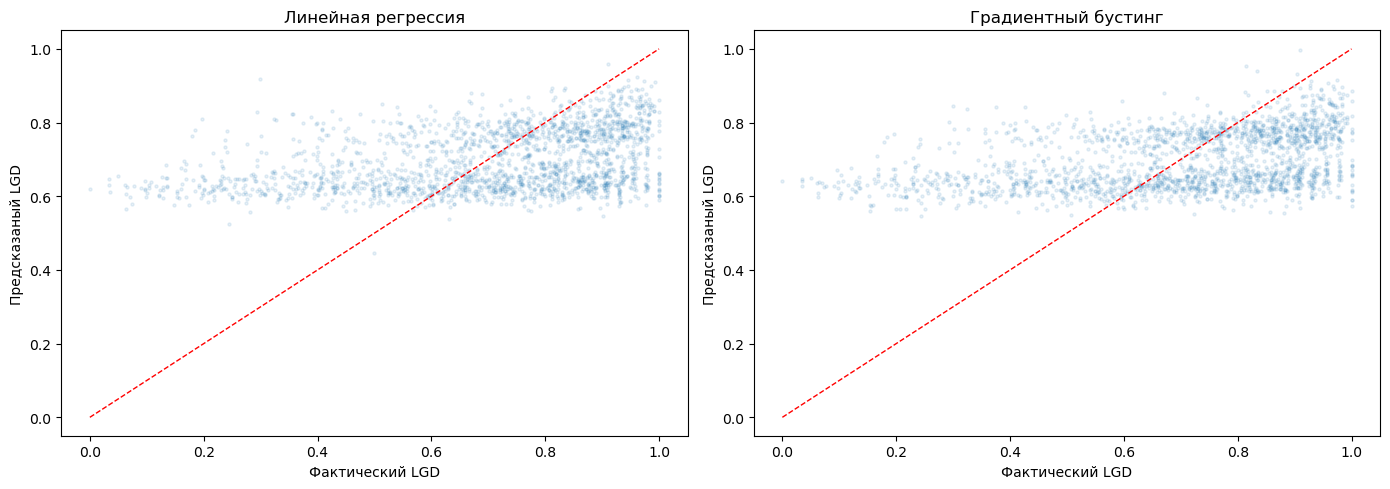

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, title in zip(
    axes,
    [y_pred_lr, y_pred_gbm],
    ['Линейная регрессия', 'Градиентный бустинг']
):
    ax.scatter(y_test[:2000], preds[:2000], alpha=0.1, s=5)
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1)
    ax.set_xlabel('Фактический LGD')
    ax.set_ylabel('Предсказаный LGD')
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [9]:
# для расчёта EL будем использовать константный LGD
LGD_CONSTANT = df['lgd_actual'].mean()

print(f"Константный LGD (pooled): {LGD_CONSTANT:.3f}")
print(f"GBM LGD RMSE: {metrics_gbm['RMSE']:.4f}")
print(round(df['lgd_actual'].std(),4))

Константный LGD (pooled): 0.697
GBM LGD RMSE: 0.2023
0.2187


In [10]:
con.close()